# Two noise biases in the cosine, in miniature

[`claude_notes/stim_belief_alignment_updated.md`](../claude_notes/stim_belief_alignment_updated.md)

The A/B/C alignment design reads one number off three estimated group means:

```
v_stim = r_B - r_A          v_pref = r_C - r_B          cos(v_stim, v_pref)
```

Noise in those means corrupts that number in two separate ways, by two different mechanisms:

1. **Issue 1 -- the shared group B drags the numerator down.** Both vectors are built from the
   same estimated `r_B`, with opposite signs, so its noise enters both and the cross-term does
   not cancel: `E<eps_stim, eps_pref> = E<e_B - e_A, e_C - e_B> = -E||e_B||^2 < 0`. **Part 1.**
2. **Attenuation -- noise inflates the denominator.** `E||v_hat||^2 = ||v||^2 + noise power`,
   strictly larger than the truth for any noise at all, so whatever the numerator says gets
   shrunk toward 0. **Part 2.**

Both are *second-order* in the noise -- exactly zero to first order, which is why neither shows
up when reasoning about the design in terms of expected group means, and why both are easy to
miss. Both have the same geometric shape in 2-D: the true point sits exactly on a curved
boundary, and the curvature decides the split. **Part 3** then drops the toy for the note's real
numbers and asks whether the two proposed fixes recover the truth.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

plt.rcParams.update({"font.size": 15})

# Every scatter colors B_hat by which side of a boundary it landed on -- sign of the cosine in
# part 1, short-vs-long and then small-vs-large cosine in part 2 -- with NEG_COLOR always on the
# side the bias pushes toward, so the pictures read the same way. A polarity encoding, so a
# CVD-safe warm/cool pair (Okabe-Ito); checked with the dataviz validator: worst-pair deltaE
# 21.9 protan / 31.2 normal.
POS_COLOR = "#0072B2"
NEG_COLOR = "#D55E00"
# estimators, in part 3. NEG_COLOR stays on the broken one so the "this is the bad case" reading
# carries over from the earlier figures.
EST_COLORS = {"cos_raw, shared B": NEG_COLOR, "cos_raw, split B": POS_COLOR, "cos_unb, shared B": "#009E73"}
INK, MUTED = "#222222", "#888888"

# shared by both toys: same noise level, same number of simulated (feature, bin) draws
N_DRAWS = 1000
SIGMA = 0.2


def style(ax):
    """Recessive grid, no top/right spines."""
    ax.set_axisbelow(True)
    ax.grid(True, color="#e6e6e6", linewidth=1)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#cccccc")
    return ax


def cos_sim(v1, v2):
    """Row-wise cosine similarity between two (n, d) stacks of vectors."""
    return np.sum(v1 * v2, axis=-1) / (np.linalg.norm(v1, axis=-1) * np.linalg.norm(v2, axis=-1))


def frac_outside_leading_order(sigma, radius):
    """
    Leading-order P(a draw lands outside the boundary circle), for an isotropic 2-D Gaussian
    centered on a circle of radius R: 0.5 + sigma / (2 R sqrt(2 pi)). Both parts use it; the only
    thing that changes between them is which circle.
    """
    return 0.5 + sigma / (2 * radius * np.sqrt(2 * np.pi))

## Part 1 -- the shared group B drags the numerator down

Three groups at fixed true positions

```
A = (0, 0)      B = (1, 0)      C = (1, 1)
```

chosen so the two true axes are exactly orthogonal (`v_stim = (1, 0)`, `v_pref = (0, 1)`, true
cosine 0) -- i.e. **hypothesis H1**, the null this design is supposed to be able to report. A and
C are observed without noise; only B is noisy, `B_hat ~ B + N(0, sigma^2 I)`, and each of the
N draws is one simulated (feature, time bin). Everything in this part asks the same question:
does the measured cosine come back at 0?

In [2]:
A = np.array([0.0, 0.0])
B = np.array([1.0, 0.0])
C = np.array([1.0, 1.0])

rng = np.random.default_rng(0)


def sample_shared(n, sigma, rng):
    """The design as written: one B_hat feeds both vectors, entering with opposite signs."""
    b_hat = B + rng.normal(0, sigma, size=(n, 2))
    return b_hat, b_hat - A, C - b_hat


b_hat, v_stim, v_pref = sample_shared(N_DRAWS, SIGMA, rng)
cos = cos_sim(v_stim, v_pref)
is_neg = cos < 0

print(f"sigma = {SIGMA}, N = {N_DRAWS}   true cos = 0")
print(f"  mean cos   {cos.mean():+.4f}")
print(f"  median cos {np.median(cos):+.4f}")
print(f"  frac < 0   {is_neg.mean():.3f}")
print(f"  mean <v_stim, v_pref>  {np.sum(v_stim * v_pref, -1).mean():+.4f}   (predicted -d*sigma^2 = {-2 * SIGMA ** 2:+.4f})")

sigma = 0.2, N = 1000   true cos = 0
  mean cos   -0.0016
  median cos -0.0435
  frac < 0   0.559
  mean <v_stim, v_pref>  -0.0793   (predicted -d*sigma^2 = -0.0800)


### Figure 1 -- the requested picture

The sign of `<B_hat - A, C - B_hat>` has an exact geometric boundary. The locus where the dot
product is zero is the set of points seeing segment `AC` at a right angle: **the circle with
diameter AC** (Thales). Inside that circle the angle at `B_hat` is obtuse and the cosine is
positive; outside it the angle is acute and the cosine is negative.

The true B sits *exactly on* that circle -- which is just a restatement of "the true axes are
orthogonal". So the noise is splitting a cloud straddling a boundary that passes right through
its center.

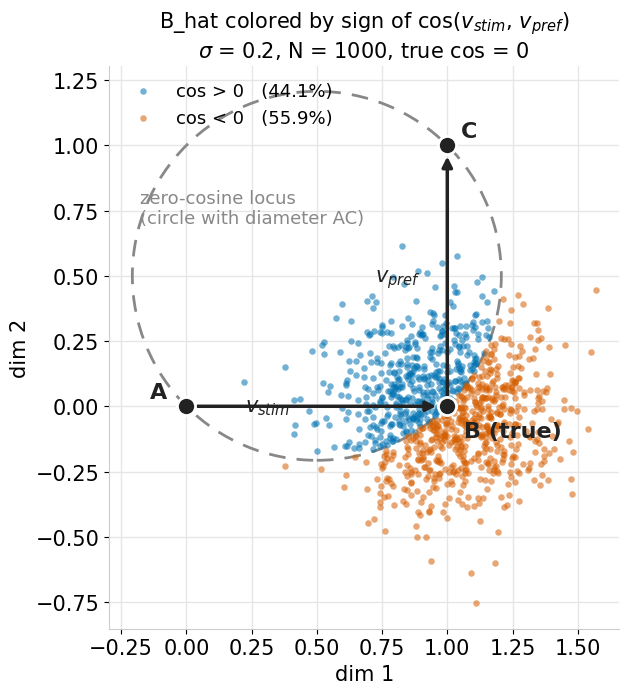

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
style(ax)

# the zero-cosine locus, drawn as a reference rather than a series -- gray, dashed.
center, radius = (A + C) / 2, np.linalg.norm(C - A) / 2
ax.add_patch(plt.Circle(center, radius, fill=False, linestyle=(0, (6, 4)), linewidth=2, edgecolor=MUTED, zorder=2))
ax.annotate(
    "zero-cosine locus\n(circle with diameter AC)", xy=(0.06, 0.72), xycoords="axes fraction",
    color=MUTED, fontsize=13, ha="left",
)

for mask, color, label in (
    (~is_neg, POS_COLOR, f"cos > 0   ({(~is_neg).mean():.1%})"),
    (is_neg, NEG_COLOR, f"cos < 0   ({is_neg.mean():.1%})"),
):
    ax.scatter(b_hat[mask, 0], b_hat[mask, 1], s=22, color=color, alpha=0.55, linewidths=0, label=label, zorder=3)

# the noiseless axes v_stim and v_pref
for start, end, name in ((A, B, "$v_{stim}$"), (B, C, "$v_{pref}$")):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", linewidth=2.5, color=INK, shrinkA=8, shrinkB=8), zorder=4)
    mid = (start + end) / 2
    ax.annotate(name, mid, textcoords="offset points", xytext=(-52, -4), fontsize=15, color=INK, zorder=6)

# direct labels on the three anchors, with a 2px surface ring so they read over the cloud
for point, name, offset in ((A, "A", (-26, 6)), (B, "B (true)", (12, -22)), (C, "C", (10, 6))):
    ax.scatter(*point, s=170, color=INK, edgecolors="white", linewidths=2, zorder=5)
    ax.annotate(name, point, textcoords="offset points", xytext=offset, fontsize=16, fontweight="bold", color=INK, zorder=6)

ax.set_aspect("equal")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.set_title(f"B_hat colored by sign of cos($v_{{stim}}$, $v_{{pref}}$)\n$\\sigma$ = {SIGMA}, N = {N_DRAWS}, true cos = 0", fontsize=15)
ax.legend(frameon=False, loc="upper left", fontsize=13)
plt.tight_layout()
plt.show()

**The split is not 50/50, and the reason is curvature.** If the boundary were a straight line
through B, an isotropic cloud centered on B would land on each side exactly half the time and
there would be no bias at all. It is a circle, and it curves *away* from the outside region, so
a neighborhood of B contains slightly more "outside" (negative) than "inside" (positive) area.

To leading order, for a Gaussian centered on a circle of radius `R`:

```
P(outside) ~ 0.5 + sigma / (2 R sqrt(2 pi))
```

which for `sigma = 0.2` and the Thales circle's `R = sqrt(2)/2` gives 0.556 -- matched below.
This is the geometric face of the `-E||e_B||^2` cross-term: it is a second-order effect, zero to
first order in the noise, which is why it is easy to miss when reasoning about the design. Part 2
runs into the same formula with a different circle.

In [4]:
frac_out = (np.linalg.norm(b_hat - center, axis=-1) > radius).mean()
print(f"frac outside circle {frac_out:.4f}   frac cos < 0 {is_neg.mean():.4f}   (identical by construction)")
print(f"leading-order prediction {frac_outside_leading_order(SIGMA, radius):.4f}")

frac outside circle 0.5590   frac cos < 0 0.5590   (identical by construction)
leading-order prediction 0.5564


### Figure 2 -- the distribution, and how the bias grows with noise

One thing the scatter hides: **the mean and the median of the cosine are not the same story.**
At `sigma = 0.2` the median is clearly negative while the mean is nearly 0, because the
distribution is left-shifted but right-skewed. The cosine is a *ratio*, and the same noise that
makes the numerator negative also inflates the denominator, damping the excursion. That
inflation is Part 2's subject.

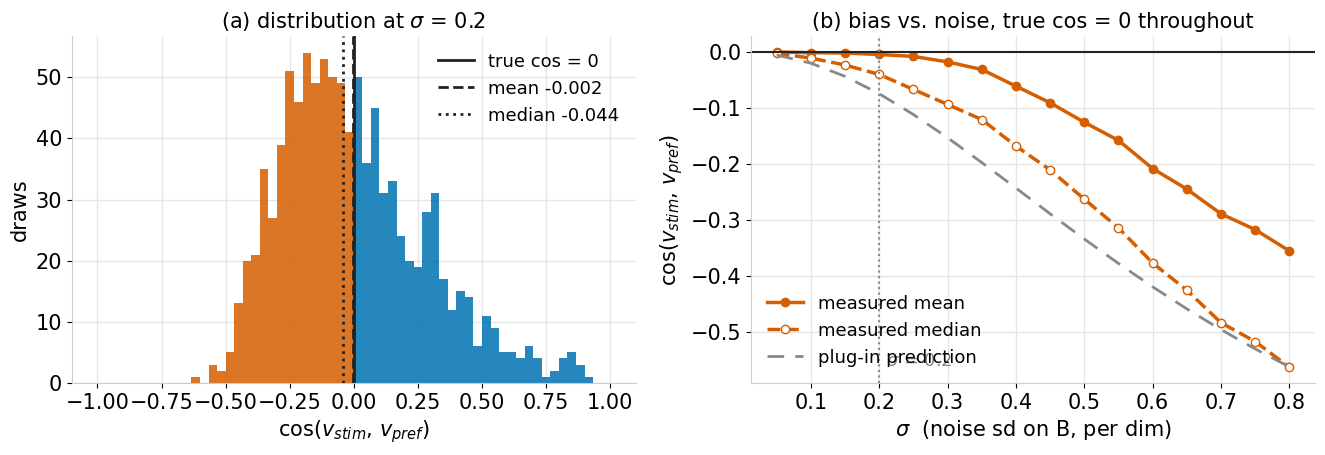

In [5]:
SIGMA_GRID = np.round(np.arange(0.05, 0.85, 0.05), 3)
N_SWEEP = 20000
sweep_rng = np.random.default_rng(7)

rows = []
for sigma in SIGMA_GRID:
    _, vs, vp = sample_shared(N_SWEEP, sigma, sweep_rng)
    c = cos_sim(vs, vp)
    # plug-in prediction: bias of the numerator over sqrt of the E of the two squared norms,
    # which is the arithmetic the note uses to land on -0.65.
    plug = (-2 * sigma ** 2) / np.sqrt((1 + 2 * sigma ** 2) * (1 + 2 * sigma ** 2))
    rows.append(dict(sigma=sigma, mean=c.mean(), median=np.median(c), frac_neg=(c < 0).mean(), plug_in=plug))
sweep = pd.DataFrame(rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))

# (a) the distribution at the default sigma, bars carrying the fig-1 sign encoding
style(ax1)
bins = np.linspace(-1, 1, 61)
ax1.hist(cos[~is_neg], bins=bins, color=POS_COLOR, alpha=0.85, linewidth=0)
ax1.hist(cos[is_neg], bins=bins, color=NEG_COLOR, alpha=0.85, linewidth=0)
ax1.axvline(0, color=INK, linewidth=2, label="true cos = 0")
ax1.axvline(cos.mean(), color=INK, linewidth=2, linestyle="dashed", label=f"mean {cos.mean():+.3f}")
ax1.axvline(np.median(cos), color=INK, linewidth=2, linestyle="dotted", label=f"median {np.median(cos):+.3f}")
ax1.set_xlabel("cos($v_{stim}$, $v_{pref}$)")
ax1.set_ylabel("draws")
ax1.set_title(f"(a) distribution at $\\sigma$ = {SIGMA}", fontsize=15)
ax1.legend(frameon=False, fontsize=13)

# (b) how it grows with noise
style(ax2)
ax2.plot(sweep.sigma, sweep["mean"], color=NEG_COLOR, linewidth=2.5, marker="o", markersize=6, label="measured mean")
ax2.plot(sweep.sigma, sweep["median"], color=NEG_COLOR, linewidth=2.5, marker="o", markersize=6, linestyle="dashed", markerfacecolor="white", label="measured median")
ax2.plot(sweep.sigma, sweep.plug_in, color=MUTED, linewidth=2, linestyle=(0, (6, 4)), label="plug-in prediction")
ax2.axhline(0, color=INK, linewidth=1.5)
ax2.axvline(SIGMA, color=MUTED, linewidth=1.5, linestyle="dotted")
ax2.annotate(f"$\\sigma$ = {SIGMA}", xy=(SIGMA, ax2.get_ylim()[0]), textcoords="offset points", xytext=(5, 12), color=MUTED, fontsize=13)
ax2.set_xlabel("$\\sigma$  (noise sd on B, per dim)")
ax2.set_ylabel("cos($v_{stim}$, $v_{pref}$)")
ax2.set_title("(b) bias vs. noise, true cos = 0 throughout", fontsize=15)
ax2.legend(frameon=False, fontsize=13, loc="lower left")

plt.tight_layout()
plt.show()

Note that in 2-D the measured mean sits *well above* the plug-in prediction the note uses. That
is not a mistake in the note -- it is a low-dimension effect, and the next figure shows it goes
away exactly where the real analysis lives.

### Figure 3 -- why 2-D understates the problem

Hold the total noise power `d * sigma^2` fixed at 1 (equal to the signal power) and vary the
dimension. In 2-D, `||e||^2` fluctuates wildly draw to draw, so the denominator co-varies with
the numerator and the ratio is pulled back toward 0. As `d` grows, `||e||^2` concentrates at
`d * sigma^2`, the denominator becomes effectively deterministic, and the mean cosine converges
onto the plug-in value.

**The real analysis is at p = 528 units -- fully in the concentrated regime.** So the note's
`-p/n_B / sqrt(...)` arithmetic is the right estimate there, and this 2-D toy is the *gentlest*
possible version of the problem, not a worst case.

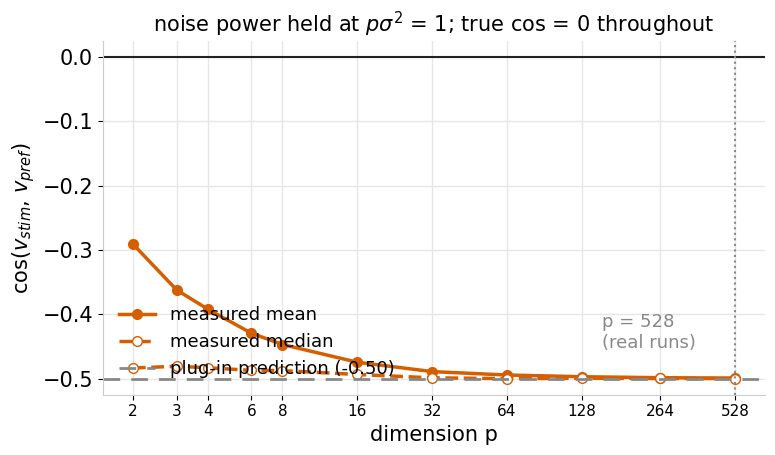

In [6]:
def sample_shared_nd(n, sigma, dim, rng, signal_sq=1.0):
    """
    Same three groups, embedded in `dim` dimensions: signal stays in the first two coordinates,
    isotropic noise fills all of them. signal_sq is the squared norm of each true axis.
    """
    scale = np.sqrt(signal_sq)
    a, b, c = np.zeros(dim), np.zeros(dim), np.zeros(dim)
    b[0] = scale
    c[0], c[1] = scale, scale
    b_hat = b + rng.normal(0, sigma, size=(n, dim))
    return b_hat - a, c - b_hat


DIMS = [2, 3, 4, 6, 8, 16, 32, 64, 128, 264, 528]
NOISE_POWER = 1.0
dim_rng = np.random.default_rng(11)

dim_rows = []
for dim in DIMS:
    sigma = np.sqrt(NOISE_POWER / dim)
    vs, vp = sample_shared_nd(20000, sigma, dim, dim_rng)
    c = cos_sim(vs, vp)
    dim_rows.append(dict(dim=dim, mean=c.mean(), median=np.median(c)))
dim_sweep = pd.DataFrame(dim_rows)
plug_in_nd = -NOISE_POWER / (1 + NOISE_POWER)

fig, ax = plt.subplots(figsize=(8, 4.8))
style(ax)
ax.plot(dim_sweep.dim, dim_sweep["mean"], color=NEG_COLOR, linewidth=2.5, marker="o", markersize=7, label="measured mean")
ax.plot(dim_sweep.dim, dim_sweep["median"], color=NEG_COLOR, linewidth=2.5, marker="o", markersize=7, linestyle="dashed", markerfacecolor="white", label="measured median")
ax.axhline(plug_in_nd, color=MUTED, linewidth=2, linestyle=(0, (6, 4)), label=f"plug-in prediction ({plug_in_nd:+.2f})")
ax.axhline(0, color=INK, linewidth=1.5)
ax.axvline(528, color=MUTED, linewidth=1.5, linestyle="dotted")
ax.annotate("p = 528\n(real runs)", xy=(528, plug_in_nd), textcoords="offset points", xytext=(-96, 22), color=MUTED, fontsize=13, ha="left")
ax.set_xscale("log", base=2)
ax.set_xticks(DIMS)
ax.set_xticklabels(DIMS, fontsize=11)
ax.set_xlabel("dimension p")
ax.set_ylabel("cos($v_{stim}$, $v_{pref}$)")
ax.set_title("noise power held at $p\\sigma^2$ = 1; true cos = 0 throughout", fontsize=15)
ax.legend(frameon=False, fontsize=13, loc="lower left")
plt.tight_layout()
plt.show()

## Part 2 -- attenuation inflates the denominator

Different mechanism, same noise, and it outlives Part 1: fix (a) removes the numerator bias and
makes *this* one worse, since splitting B doubles the noise carried by each vector.

Drop the cosine for a moment and look at a single axis. One true vector runs from `A = (0, 0)` to
`B = (1, 1)`; A is exact and `B_hat ~ B + N(0, sigma^2 I)` as before. The measured axis is
`B_hat - A`, and because the noise is independent of the signal, its squared length picks up the
whole noise power:

```
E||B_hat - A||^2 = ||B - A||^2 + d sigma^2
```

Noise adds length in expectation; it can never remove it. That squared length is the denominator
of every cosine in Part 1, so a measured cosine is shrunk toward 0 by the attenuation factor

```
att = ||B - A|| / sqrt(||B - A||^2 + d sigma^2)
```

one factor per axis. This is the `sq_stim` / `sq_pref` correction of fix (b) in the note seen
from the other side -- and it is where the `(1 + 2 sigma^2)` in Figure 2's plug-in prediction
came from.

In [7]:
A2 = np.array([0.0, 0.0])
B2 = np.array([1.0, 1.0])

att_rng = np.random.default_rng(3)
b2_hat = B2 + att_rng.normal(0, SIGMA, size=(N_DRAWS, 2))

true_len = np.linalg.norm(B2 - A2)
meas_len = np.linalg.norm(b2_hat - A2, axis=-1)
rms_len = np.sqrt((meas_len ** 2).mean())
is_short = meas_len < true_len

print(f"sigma = {SIGMA}, N = {N_DRAWS}   true ||B - A|| = {true_len:.4f}")
print(f"  mean ||B_hat - A||  {meas_len.mean():.4f}")
print(f"  rms  ||B_hat - A||  {rms_len:.4f}   (predicted sqrt(||B-A||^2 + d*sigma^2) = {np.sqrt(true_len ** 2 + 2 * SIGMA ** 2):.4f})")
print(f"  frac shorter than truth {is_short.mean():.3f}   (leading order {1 - frac_outside_leading_order(SIGMA, true_len):.3f})")
print(f"  attenuation factor ||B-A|| / rms  {true_len / rms_len:.4f}")

sigma = 0.2, N = 1000   true ||B - A|| = 1.4142
  mean ||B_hat - A||  1.4354
  rms  ||B_hat - A||  1.4495   (predicted sqrt(||B-A||^2 + d*sigma^2) = 1.4422)
  frac shorter than truth 0.458   (leading order 0.472)
  attenuation factor ||B-A|| / rms  0.9757


### Figure 4 -- B_hat colored by whether the measured length came out short

Figure 1's picture with a different boundary. "Measured shorter than the truth" is exactly
"inside the circle of radius `||B - A||` centered at A"; the true B sits exactly on that circle;
and the circle curves away from the outside, so more than half the draws land long. Same
leading-order formula as before, `0.5 + sigma / (2 R sqrt(2 pi))`, evaluated now at this circle's
`R = sqrt(2)` rather than the Thales circle's `sqrt(2)/2`. Twice the radius means a flatter
boundary and a milder split: 52.8/47.2 predicted, against Figure 1's 55.6/44.4. (These are the
same 1000 draws Figure 1 used, and at N = 1000 the sampling sd on that proportion is 1.6 points,
so the cloud below reads 54.2/45.8 -- the check that matters is the closed form in Figure 5b, not
this count.)

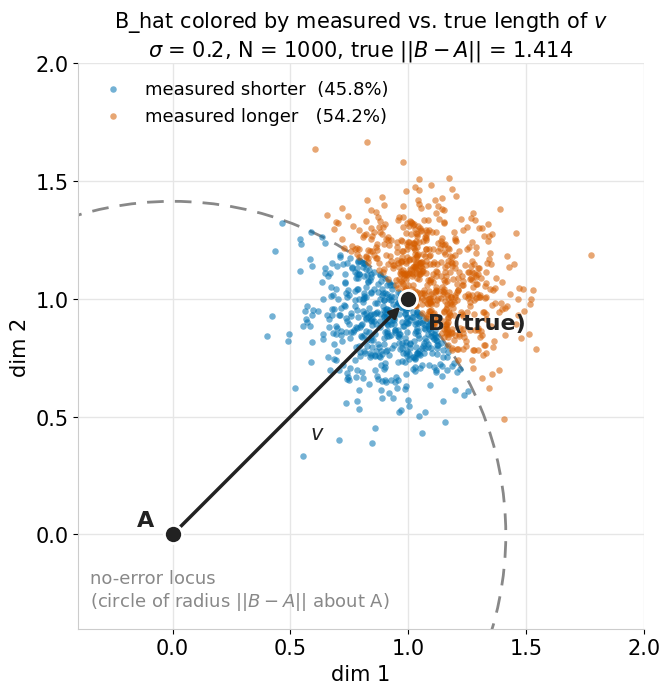

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
style(ax)

# the boundary, drawn as a reference rather than a series -- gray, dashed. The measured length
# equals the true length exactly on the circle of radius ||B - A|| centered at A.
ax.add_patch(plt.Circle(A2, true_len, fill=False, linestyle=(0, (6, 4)), linewidth=2, edgecolor=MUTED, zorder=2))
ax.annotate(
    "no-error locus\n(circle of radius $||B - A||$ about A)", xy=(0.02, 0.04), xycoords="axes fraction",
    color=MUTED, fontsize=13, ha="left",
)

for mask, color, label in (
    (is_short, POS_COLOR, f"measured shorter  ({is_short.mean():.1%})"),
    (~is_short, NEG_COLOR, f"measured longer   ({(~is_short).mean():.1%})"),
):
    ax.scatter(b2_hat[mask, 0], b2_hat[mask, 1], s=22, color=color, alpha=0.55, linewidths=0, label=label, zorder=3)

# the noiseless axis
ax.annotate("", xy=B2, xytext=A2, arrowprops=dict(arrowstyle="-|>", linewidth=2.5, color=INK, shrinkA=8, shrinkB=8), zorder=4)
ax.annotate("$v$", (A2 + B2) / 2, textcoords="offset points", xytext=(14, -16), fontsize=15, color=INK, zorder=6)

# direct labels on the two anchors, with a 2px surface ring so they read over the cloud
for point, name, offset in ((A2, "A", (-26, 6)), (B2, "B (true)", (14, -22))):
    ax.scatter(*point, s=170, color=INK, edgecolors="white", linewidths=2, zorder=5)
    ax.annotate(name, point, textcoords="offset points", xytext=offset, fontsize=16, fontweight="bold", color=INK, zorder=6)

ax.set_aspect("equal")
ax.set_xlim(-0.4, 2.0)
ax.set_ylim(-0.4, 2.0)
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.set_title(f"B_hat colored by measured vs. true length of $v$\n$\\sigma$ = {SIGMA}, N = {N_DRAWS}, true $||B - A||$ = {true_len:.3f}", fontsize=15)
ax.legend(frameon=False, loc="upper left", fontsize=13)
plt.tight_layout()
plt.show()

Counting draws understates this one, though. The question that matters is not how *often* the
measured axis comes out long but how much length it gains -- and while the overshoot in the mean
length is second-order and small, the overshoot in the *squared* length is exactly `d sigma^2`,
first-order in the noise power. The squared length is what the cosine's denominator uses.

### Figure 5 -- what that costs the cosine

(a) the measured lengths at `sigma = 0.2`; (b) the attenuation factor across noise levels against
the closed form. Two things to read off (b). The shrink is toward 0 regardless of the sign of the
true cosine, so it is never "conservative" in a useful direction -- under H2 it would hide
alignment exactly as readily as it hides anti-alignment under H1. And it depends only on the
*total* noise power relative to the signal, so unlike Figure 3's effect it does not care about
the dimension: the 2-D toy is honest about this one.

At the note's numbers the two factors come out at `att_stim ~ 0.71` and `att_pref ~ 0.60`
(printed in Part 3), so even with Part 1's numerator bias fully removed, a true cosine of 0.5
would be reported near `0.5 * 0.71 * 0.60 = 0.21`.

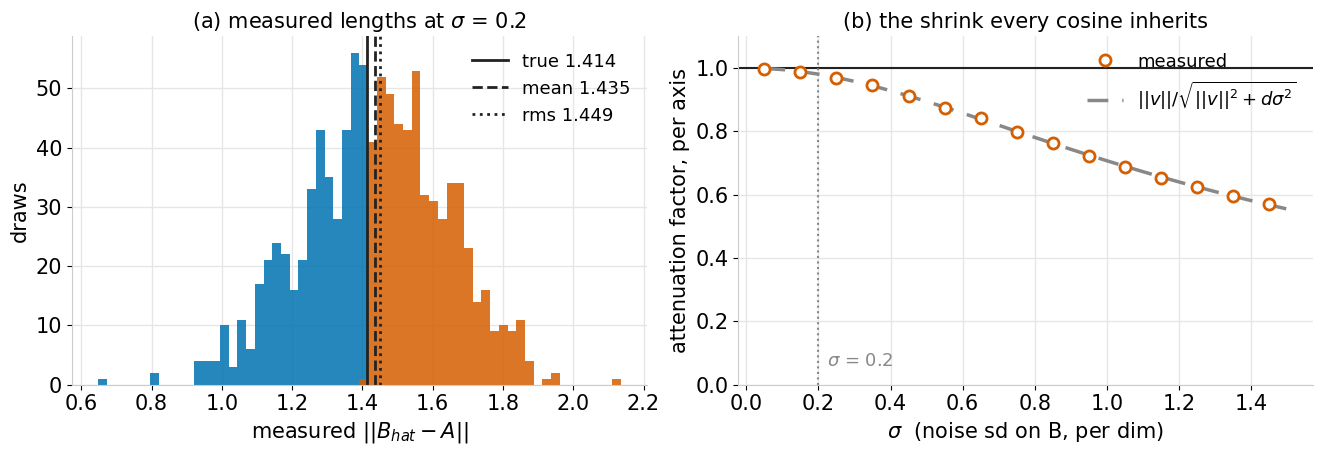

In [9]:
ATT_SIGMA_GRID = np.round(np.arange(0.05, 1.55, 0.05), 3)
att_sweep_rng = np.random.default_rng(5)

att_rows = []
for sigma in ATT_SIGMA_GRID:
    lens = np.linalg.norm(B2 + att_sweep_rng.normal(0, sigma, size=(20000, 2)) - A2, axis=-1)
    att_rows.append(dict(sigma=sigma, att=true_len / np.sqrt((lens ** 2).mean()), frac_short=(lens < true_len).mean()))
att_sweep = pd.DataFrame(att_rows)
att_closed_form = true_len / np.sqrt(true_len ** 2 + 2 * ATT_SIGMA_GRID ** 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))

# (a) the measured lengths at the default sigma, bars carrying the fig-4 short/long encoding
style(ax1)
bins = np.linspace(meas_len.min(), meas_len.max(), 61)
ax1.hist(meas_len[is_short], bins=bins, color=POS_COLOR, alpha=0.85, linewidth=0)
ax1.hist(meas_len[~is_short], bins=bins, color=NEG_COLOR, alpha=0.85, linewidth=0)
ax1.axvline(true_len, color=INK, linewidth=2, label=f"true {true_len:.3f}")
ax1.axvline(meas_len.mean(), color=INK, linewidth=2, linestyle="dashed", label=f"mean {meas_len.mean():.3f}")
ax1.axvline(rms_len, color=INK, linewidth=2, linestyle="dotted", label=f"rms {rms_len:.3f}")
ax1.set_xlabel("measured $||B_{hat} - A||$")
ax1.set_ylabel("draws")
ax1.set_title(f"(a) measured lengths at $\\sigma$ = {SIGMA}", fontsize=15)
ax1.legend(frameon=False, fontsize=13)

# (b) the shrink factor vs noise, against the closed form
style(ax2)
# open markers over the closed form, so the agreement is visible rather than painted over
ax2.plot(att_sweep.sigma[::2], att_sweep.att[::2], color=NEG_COLOR, linestyle="none", marker="o",
         markersize=8, markerfacecolor="white", markeredgewidth=2, zorder=3, label="measured")
ax2.plot(ATT_SIGMA_GRID, att_closed_form, color=MUTED, linewidth=2.5, linestyle=(0, (6, 4)), zorder=2,
         label="$||v|| / \\sqrt{||v||^2 + d\\sigma^2}$")
ax2.axhline(1, color=INK, linewidth=1.5, zorder=1)
ax2.axvline(SIGMA, color=MUTED, linewidth=1.5, linestyle="dotted", zorder=1)
ax2.annotate(f"$\\sigma$ = {SIGMA}", xy=(SIGMA, 0.06), textcoords="offset points", xytext=(6, 0), color=MUTED, fontsize=13)
ax2.set_ylim(0, 1.1)
ax2.set_xlabel("$\\sigma$  (noise sd on B, per dim)")
ax2.set_ylabel("attenuation factor, per axis")
ax2.set_title("(b) the shrink every cosine inherits", fontsize=15)
ax2.legend(frameon=False, fontsize=13, loc="upper right")

plt.tight_layout()
plt.show()

### Figure 6 -- attenuation acting directly on a cosine

Figures 4 and 5 measured a length. This one measures the quantity the analysis actually reports.
Move the third group so the true cosine is not 0:

```
A = (0, 0)      B = (1, 1)      C = (1, 0)
```

`B_hat` is drawn exactly as before, and the measured quantity is `cos(B_hat - A, C - A)` -- one
noisy axis against an exact reference, with a true value of `cos 45deg = 0.7071`.

The boundary is **straight this time**. A cosine ignores length and sees only the *direction* of
`B_hat - A`, so every point on the ray A->B measures exactly the true cosine, and the two sides
of that ray are "angle wider, cosine smaller" and "angle narrower, cosine larger". The cloud is
centered on a straight boundary, so unlike Figures 1 and 4 the split is 50/50 and the *median*
measured cosine is the true one. The mean is shrunk anyway.

In [10]:
A3 = np.array([0.0, 0.0])
B3 = np.array([1.0, 1.0])
C3 = np.array([1.0, 0.0])

cos_rng = np.random.default_rng(7)
b3_hat = B3 + cos_rng.normal(0, SIGMA, size=(N_DRAWS, 2))

L = np.linalg.norm(B3 - A3)
true_cos = cos_sim(B3 - A3, C3 - A3)
cos3 = cos_sim(b3_hat - A3, C3 - A3)
is_below = cos3 < true_cos

# only the noise component *perpendicular* to v turns the axis; the parallel component changes
# the length, which the cosine divides straight back out. So the angular error has variance
# ~ sigma^2/L^2 per perpendicular direction, and E[cos] ~ true_cos * (1 - (d-1) sigma^2 / 2L^2).
perp_pred = true_cos * (1 - (2 - 1) * SIGMA ** 2 / (2 * L ** 2))

se = cos3.std(ddof=1) / np.sqrt(N_DRAWS)

print(f"sigma = {SIGMA}, N = {N_DRAWS}   true cos = {true_cos:.4f}")
print(f"  mean cos    {cos3.mean():.4f} +/- {se:.4f} (SE)   (perpendicular-noise prediction {perp_pred:.4f})")
print(f"  median cos  {np.median(cos3):.4f}   (true {true_cos:.4f})")
print(f"  frac below true {is_below.mean():.3f} +/- {np.sqrt(0.25 / N_DRAWS):.3f}")
print(f"  predicted shift in the mean {perp_pred - true_cos:+.4f} = {abs(perp_pred - true_cos) / se:.1f} SE, so a single")
print(f"    {N_DRAWS}-draw sample cannot resolve it -- the 50k-per-level sweep below can.")
print(f"  norm-based att from fig 5b, for comparison: {L / np.sqrt(L ** 2 + 2 * SIGMA ** 2):.4f}")

sigma = 0.2, N = 1000   true cos = 0.7071
  mean cos    0.7091 +/- 0.0030 (SE)   (perpendicular-noise prediction 0.7000)
  median cos  0.7127   (true 0.7071)
  frac below true 0.472 +/- 0.016
  predicted shift in the mean -0.0071 = 2.3 SE, so a single
    1000-draw sample cannot resolve it -- the 50k-per-level sweep below can.
  norm-based att from fig 5b, for comparison: 0.9806


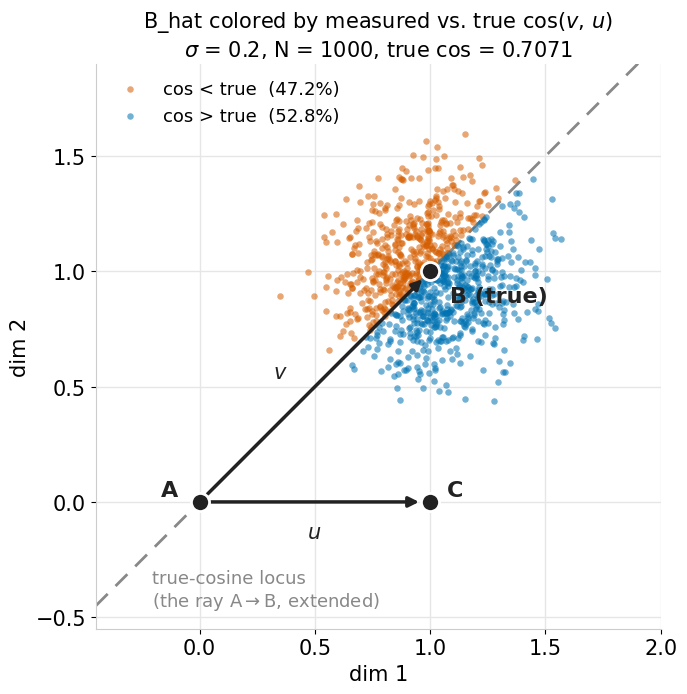

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))
style(ax)

# the boundary, drawn as a reference rather than a series -- gray, dashed. The cosine sees only
# the direction of B_hat - A, so the locus is the ray A->B extended: a straight line through the
# center of the cloud. (Its second branch, the ray at -45 deg, is far outside this noise level.)
ray = np.array([-0.45, 2.0])
ax.plot(ray, ray, linestyle=(0, (6, 4)), linewidth=2, color=MUTED, zorder=2)
ax.annotate(
    "true-cosine locus\n(the ray A$\\rightarrow$B, extended)", xy=(0.10, 0.04), xycoords="axes fraction",
    color=MUTED, fontsize=13, ha="left",
)

for mask, color, label in (
    (is_below, NEG_COLOR, f"cos < true  ({is_below.mean():.1%})"),
    (~is_below, POS_COLOR, f"cos > true  ({(~is_below).mean():.1%})"),
):
    ax.scatter(b3_hat[mask, 0], b3_hat[mask, 1], s=22, color=color, alpha=0.55, linewidths=0, label=label, zorder=3)

# the noiseless axes: v is the one that gets estimated, u is the exact reference
for start, end, name, offset in ((A3, B3, "$v$", (-30, 6)), (A3, C3, "$u$", (-6, -26))):
    ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", linewidth=2.5, color=INK, shrinkA=8, shrinkB=8), zorder=4)
    ax.annotate(name, (start + end) / 2, textcoords="offset points", xytext=offset, fontsize=15, color=INK, zorder=6)

# direct labels on the three anchors, with a 2px surface ring so they read over the cloud
for point, name, offset in ((A3, "A", (-28, 4)), (B3, "B (true)", (14, -22)), (C3, "C", (12, 4))):
    ax.scatter(*point, s=170, color=INK, edgecolors="white", linewidths=2, zorder=5)
    ax.annotate(name, point, textcoords="offset points", xytext=offset, fontsize=16, fontweight="bold", color=INK, zorder=6)

ax.set_aspect("equal")
ax.set_xlim(-0.45, 2.0)
ax.set_ylim(-0.55, 1.9)
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.set_title(f"B_hat colored by measured vs. true cos($v$, $u$)\n$\\sigma$ = {SIGMA}, N = {N_DRAWS}, true cos = {true_cos:.4f}", fontsize=15)
ax.legend(frameon=False, loc="upper left", fontsize=13)
plt.tight_layout()
plt.show()

**A 50/50 split and a biased mean at the same time.** The angular error is symmetric about 0 --
the cloud is symmetric across the ray -- but the cosine is *curved* in the angle, so a wider
angle costs more than an equally-sized narrower angle gains:

```
E cos(theta + delta) = cos(theta) * E cos(delta)  <  cos(theta)
```

Always toward 0, never away. Two consequences worth carrying: **a count- or sign-based check
cannot see this bias**, since the counts are 50/50 by construction, and **the median is the
robust statistic here while the mean is not** -- the opposite of the situation in Part 1, where
the median moved and the mean barely did.

The sweep below runs 50,000 draws per noise level, because at `sigma = 0.2` the predicted shift
is roughly two standard errors of a 1000-draw mean. The scatter above is honest about the
*geometry* and powerless about the *bias* -- which is itself worth absorbing: this is not
something an eyeballed cloud, or a modest number of sessions, will reveal.

Two details it brings out. The shrink measured here (mean/true) is *milder* than the norm-based
attenuation factor of Figure 5b, because only the noise perpendicular to `v` rotates the axis --
the parallel component inflates numerator and denominator together and divides straight back out.
In `d` dimensions that is a `(d-1)/d` correction: negligible at `p = 528`, but a factor of 2 in
this 2-D toy, the same low-dimension caveat as Figure 3. (Both expressions are second-order, so
the comparison stops meaning much by the bottom row, where `sigma` is comparable to `||v||`.) And
the 50/50 count split holds only while the cloud stays clear of the locus's second branch, the
ray at -45 deg; past `sigma ~ 0.5` the counts start to tilt and the median goes with them.

In [12]:
COS_SIGMA_GRID = np.round(np.arange(0.1, 1.05, 0.1), 3)
cos_sweep_rng = np.random.default_rng(9)

cos_rows = []
for sigma in COS_SIGMA_GRID:
    c = cos_sim(B3 + cos_sweep_rng.normal(0, sigma, size=(50000, 2)) - A3, C3 - A3)
    cos_rows.append(dict(
        sigma=sigma, mean=c.mean(), median=np.median(c), frac_below=(c < true_cos).mean(),
        shrink=c.mean() / true_cos,
        perp_pred=1 - sigma ** 2 / (2 * L ** 2),   # (d - 1) = 1 perpendicular direction in 2-D
        norm_att=L / np.sqrt(L ** 2 + 2 * sigma ** 2),
    ))
print(f"true cos = {true_cos:.4f}")
print(pd.DataFrame(cos_rows).to_string(index=False, float_format=lambda v: f"{v:.4f}"))

true cos = 0.7071
 sigma   mean  median  frac_below  shrink  perp_pred  norm_att
0.1000 0.7055  0.7070      0.5009  0.9977     0.9975    0.9950
0.2000 0.6999  0.7076      0.4982  0.9898     0.9900    0.9806
0.3000 0.6908  0.7076      0.4985  0.9769     0.9775    0.9578
0.4000 0.6773  0.7074      0.4994  0.9578     0.9600    0.9285
0.5000 0.6553  0.7045      0.5037  0.9267     0.9375    0.8944
0.6000 0.6307  0.7034      0.5046  0.8919     0.9100    0.8575
0.7000 0.5995  0.6994      0.5100  0.8478     0.8775    0.8192
0.8000 0.5667  0.6884      0.5201  0.8014     0.8400    0.7809
0.9000 0.5327  0.6775      0.5284  0.7533     0.7975    0.7433
1.0000 0.4964  0.6574      0.5432  0.7019     0.7500    0.7071


## Part 3 -- do the two proposed fixes actually recover 0?

Both biases at once, now at the note's own numbers rather than the toy's: `p = 528`, `n_A = 294`,
`n_B = n_C = 47`, per-unit z-scored variance 1, so each group mean carries noise sd `1/sqrt(n_G)`
per unit. All three groups are noisy here. True axes stay orthogonal, so the answer is still 0.

The signal norm is a free parameter and it matters a lot, because the raw cosine's bias is a
*ratio* of the two effects above -- Part 1's numerator bias over Part 2's inflated denominator.
More signal, smaller apparent bias. Panel (b) sweeps it; the note's headline **-0.65 is the
zero-signal end of that curve.** That dependence is the reason the raw cosine cannot be compared
across regions or time bins even qualitatively: a region with a weaker effect gets a more
negative number for that reason alone.

The three estimators:

| estimator | numerator | denominator |
|---|---|---|
| `cos_raw`, shared B | `<r_B - r_A, r_C - r_B>` | raw norms |
| `cos_raw`, split B (fix a) | `<r_B1 - r_A, r_C - r_B2>` | raw norms |
| `cos_unb`, shared B (fix b) | `<., .> + sum_u s2_B/n_B` | norms less their noise power |

### Figure 7 -- the three estimators, at the real numbers

In [13]:
P, N_A, N_B, N_C = 528, 294, 47, 47
N_SIM = 2000


def simulate_real(n_sim, signal_sq, rng, p=P, n_a=N_A, n_b=N_B, n_c=N_C):
    """
    Draw n_sim independent (feature, bin) realizations of all three group means, and return a
    tidy frame with the three estimators. Per-unit within-group variance is 1 (z-scored), so a
    group mean's per-unit noise variance is 1/n_G; split-B halves get 2/n_B.
    """
    scale = np.sqrt(signal_sq / 2)  # so each true axis has squared norm signal_sq
    r_a_true, r_b_true, r_c_true = np.zeros(p), np.zeros(p), np.zeros(p)
    r_b_true[:2] = scale
    r_c_true[:2] = scale
    r_c_true[2:4] = scale

    e = lambda n: rng.normal(0, np.sqrt(1.0 / n), size=(n_sim, p))
    r_a, r_b, r_c = r_a_true + e(n_a), r_b_true + e(n_b), r_c_true + e(n_c)
    # disjoint halves of B: independent, each with double the variance
    r_b1, r_b2 = r_b_true + e(n_b // 2), r_b_true + e(n_b - n_b // 2)

    out = {}
    out["cos_raw, shared B"] = cos_sim(r_b - r_a, r_c - r_b)
    out["cos_raw, split B"] = cos_sim(r_b1 - r_a, r_c - r_b2)

    # fix (b): correct numerator and both squared norms by their known noise power. s2 = 1 per
    # unit here, so sum_u s2_G/n_G is exactly p/n_G.
    v_stim, v_pref = r_b - r_a, r_c - r_b
    num_unb = np.sum(v_stim * v_pref, -1) + p / n_b
    sq_stim = np.sum(v_stim ** 2, -1) - (p / n_a + p / n_b)
    sq_pref = np.sum(v_pref ** 2, -1) - (p / n_b + p / n_c)
    att_stim = np.sqrt(np.clip(sq_stim, 0, None) / np.sum(v_stim ** 2, -1))
    att_pref = np.sqrt(np.clip(sq_pref, 0, None) / np.sum(v_pref ** 2, -1))
    cos_unb = num_unb / np.sqrt(np.clip(sq_stim, 1e-12, None) * np.clip(sq_pref, 1e-12, None))
    # the note's section 7 guard: refuse to report where either axis is attenuated below 0.3
    cos_unb = np.where((att_stim >= 0.3) & (att_pref >= 0.3), cos_unb, np.nan)
    out["cos_unb, shared B"] = cos_unb
    return pd.DataFrame(out), att_stim.mean(), att_pref.mean()


SIGNAL_SQ = 13.0  # equal to the stimulus axis's own noise power, i.e. a moderate effect
res, att_s, att_p = simulate_real(N_SIM, SIGNAL_SQ, np.random.default_rng(23))
print(f"signal_sq = {SIGNAL_SQ}   mean att_stim {att_s:.2f}   mean att_pref {att_p:.2f}   "
      f"guard drops {res['cos_unb, shared B'].isna().mean():.1%} of draws")
print(res.agg(["mean", "std"]).T.to_string(float_format=lambda v: f"{v:+.4f}"))

signal_sq = 13.0   mean att_stim 0.71   mean att_pref 0.60   guard drops 0.0% of draws
                     mean     std
cos_raw, shared B -0.3688 +0.0316
cos_raw, split B  +0.0008 +0.0414
cos_unb, shared B +0.0095 +0.1018


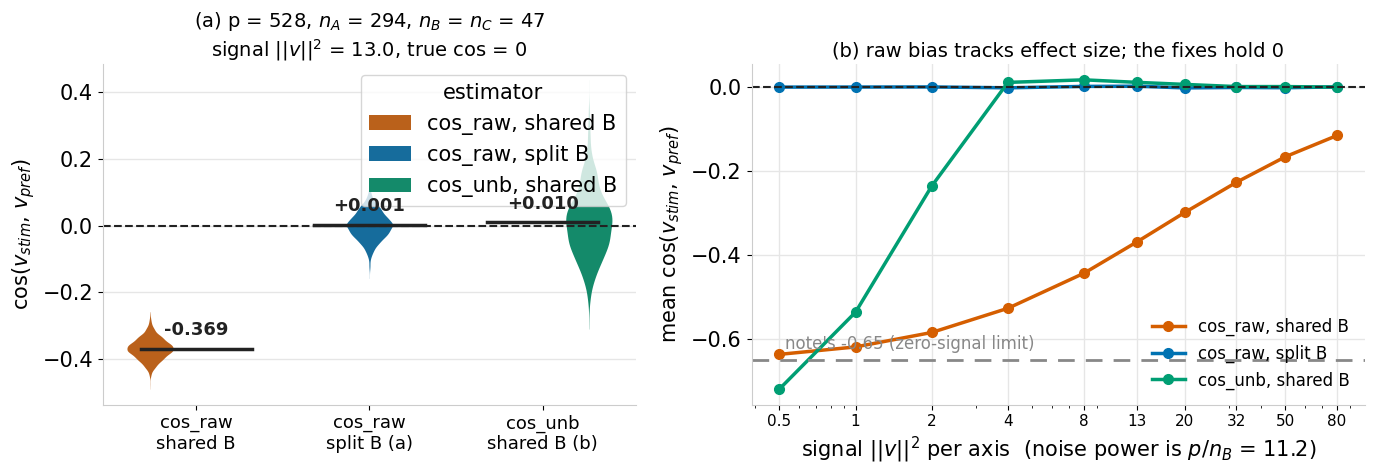

In [14]:
SIGNAL_GRID = np.array([0.5, 1, 2, 4, 8, 13, 20, 32, 50, 80])
sig_rng = np.random.default_rng(29)
sig_rows = []
for signal_sq in SIGNAL_GRID:
    r, _, _ = simulate_real(1500, signal_sq, sig_rng)
    sig_rows.append(dict(signal_sq=signal_sq, **r.mean().to_dict()))
sig_sweep = pd.DataFrame(sig_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), width_ratios=[1, 1.15])

# (a) the three estimators at one signal level
style(ax1)
order = list(EST_COLORS)
long = res.melt(var_name="estimator", value_name="cos").dropna()
sns.violinplot(long, x="estimator", y="cos", order=order, hue="estimator", hue_order=order,
               palette=EST_COLORS, legend=False, inner=None, linewidth=0, cut=0, ax=ax1)
for i, est in enumerate(order):
    m = res[est].mean()
    ax1.plot([i - 0.32, i + 0.32], [m, m], color=INK, linewidth=2.5, zorder=5)
    ax1.annotate(f"{m:+.3f}", xy=(i, m), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=13, color=INK, fontweight="bold", zorder=6)
ax1.axhline(0, color=INK, linewidth=1.5, linestyle="dashed")
ax1.set_xticks(range(len(order)))
ax1.set_xticklabels(["cos_raw\nshared B", "cos_raw\nsplit B (a)", "cos_unb\nshared B (b)"], fontsize=13)
ax1.set_xlabel("")
ax1.set_ylabel("cos($v_{stim}$, $v_{pref}$)")
ax1.set_title(f"(a) p = {P}, $n_A$ = {N_A}, $n_B$ = $n_C$ = {N_B}\nsignal $||v||^2$ = {SIGNAL_SQ}, true cos = 0", fontsize=14)

# (b) the raw bias depends on effect size; the two fixes do not
style(ax2)
for est, color in EST_COLORS.items():
    ax2.plot(sig_sweep.signal_sq, sig_sweep[est], color=color, linewidth=2.5, marker="o", markersize=7, label=est)
ax2.axhline(0, color=INK, linewidth=1.5, linestyle="dashed")
ax2.axhline(-0.65, color=MUTED, linewidth=2, linestyle=(0, (6, 4)))
ax2.annotate("note's -0.65 (zero-signal limit)", xy=(SIGNAL_GRID[0], -0.65), textcoords="offset points",
             xytext=(4, 8), color=MUTED, fontsize=12)
ax2.set_xscale("log")
ax2.set_xticks(SIGNAL_GRID)
ax2.set_xticklabels([f"{v:g}" for v in SIGNAL_GRID], fontsize=11)
ax2.set_xlabel("signal $||v||^2$ per axis  (noise power is $p/n_B$ = %.1f)" % (P / N_B))
ax2.set_ylabel("mean cos($v_{stim}$, $v_{pref}$)")
ax2.set_title("(b) raw bias tracks effect size; the fixes hold 0", fontsize=14)
ax2.legend(frameon=False, fontsize=12, loc="lower right")

plt.tight_layout()
plt.show()

## Takeaways

1. **Both biases are real, and both are geometric.** Sharing B puts the true point exactly on the
   zero-cosine boundary (fig 1); measuring a length puts it exactly on the no-error boundary
   (fig 4). Both boundaries are circles curving away from the far side, so noise pushes more than
   half the draws across. In 2-D at `sigma = 0.2` the predicted splits are 55.6/44.4 and
   52.8/47.2. Figure 6 is the instructive exception: measure a cosine against an *exact*
   reference and the boundary is straight, so the split is 50/50 and the median is unbiased
   -- while the mean is shrunk all the same. Counting which side of a boundary the draws
   land on is not a sufficient test for either bias.
2. **They act on different halves of the cosine and do not cancel.** The shared-B cross-term
   drags the numerator negative; attenuation inflates the denominator, shrinking whatever is
   there toward 0. Fixing only the numerator (fix a) makes the attenuation *worse*, since
   splitting B doubles `e_B` in each vector -- which is why the note pairs (a) with (b).
3. **The 2-D picture understates the first and is honest about the second.** The mean cosine in
   fig 2 is much less biased than the plug-in arithmetic predicts, purely because `||e||^2` is
   not concentrated in low dimension; at `p = 528` the two agree, so the note's `-0.65` is the
   number to plan against. Attenuation, by contrast, depends only on total noise power over
   signal and is the same in any dimension (fig 5b).
4. **Neither bias is a constant offset.** Both depend on the effect size (fig 7b) and on `n_B`,
   so a region or time bin with a weaker true effect gets a more negative raw cosine for that
   reason alone. This is why absorbing them into the session-permute shuffle is not enough -- the
   shuffle recenters, but it does not restore comparability across regions or across time.
5. **Both fixes work, and (a) is the cheaper one.** Splitting B into disjoint halves zeroes the
   cross-term exactly and needs no variance estimates; the full unbiased estimator (b) also
   recovers 0 but pays for it in spread, since the denominator correction is itself noisy. Fig 7a
   shows the split-B violin is wider than raw (the doubled `e_B` variance the note flags) and
   `cos_unb` wider still. Doing both, as the note proposes, is the right call: (a) for the
   numerator, (b) for the denominator attenuation that (a) makes worse.